# Learning the Pseudo Distance

## Preliminaries

In [121]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions

cpu


In [122]:
puck_list = 'all'
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst"]
head = 1000
adata, X, Y, df=load_data(gene_list=gene_list, head=head, puck_list = puck_list)
X

tensor([[ 0.0956,  0.0936],
        [ 0.4627, -0.0874],
        [ 0.0070,  0.0147],
        ...,
        [-0.1056, -0.0348],
        [ 0.0273,  0.1482],
        [-0.1410, -0.1515]], dtype=torch.float64)

In [123]:
adata.obs.columns.tolist()

['n_genes',
 'n_genes_by_counts',
 'total_counts',
 'total_counts_mt',
 'pct_counts_mt',
 'puck',
 'Age',
 'n_counts',
 'leiden',
 'leiden_12',
 'cell_type',
 'leiden_15',
 'new_annot',
 'is_oocyte',
 'id_oocyte',
 'is_granulosa',
 'granulosa_type',
 'id_follicle',
 'id_corpusluteum',
 'id_proximity_oocyte',
 'id_proximity_follicle',
 'id_proximity_corpusluteum',
 'is_theca',
 'id_theca',
 'is_mesenchyme',
 'id_mesenchyme',
 'is_immune',
 'id_immune',
 'stromal_immune',
 'is_vascular',
 'id_vascular',
 'stromal_vascular',
 'is_epithelium',
 'id_epithelium',
 'is_primordial',
 'id_primordial',
 'oocyte_label',
 'new_annot_foll',
 'tissue',
 'mouse',
 'stage',
 'batch',
 'id_oocyte_matched',
 'segment_id',
 'segment_id_extended',
 'segment_layer',
 'segment_layer_extended',
 'segment_has_oocyte',
 'segment_label',
 'segment_label_coarse',
 'segment_type',
 'MNGC',
 'is_contaminant',
 'new_annot_foll_precontamination',
 'id_oocyte_precontamination',
 'id_oocyte_matched_precontamination',


In [124]:
adata.obs['new_annot_foll']

GACTAACNTGATCA-1-0         Luteal - early
GTCGCCCNTAAAGG-1-0                 Oocyte
TCCGAACTTGGTGG-1-0                 Oocyte
GTAGAGGACNTAAG-1-0                 Muscle
TAGNGCAGGGCTCC-1-0                 Oocyte
                             ...         
GGTTCCGCTGGTCG-1-1                Stromal
AATANCACTAACTG-1-1            Endothelial
ATAGGATTGCAGGT-1-1                 Immune
GGCTAATCGGCACC-1-1    GC - antral mitotic
TAATAATTTTCCGT-1-1             Epithelial
Name: new_annot_foll, Length: 201657, dtype: category
Categories (16, object): ['Cumulus - oocyte', 'Endothelial', 'Epithelial', 'GC - antral early mitotic', ..., 'Oocyte', 'Oocyte - contaminated', 'Stromal', 'Theca']

In [125]:
adata.obs['new_annot_foll'][adata.obs['new_annot_foll'] == "GC - atretic"]

TAGTCACCTCCCAC-1-0    GC - atretic
AGGAGGGCTGCACT-1-0    GC - atretic
TTGAGCGTTGCGAC-1-0    GC - atretic
CTTNCAAAAGACTT-1-0    GC - atretic
NATAGTNAGTAGGA-1-0    GC - atretic
                          ...     
GGTATCAACTAAAC-1-1    GC - atretic
TCAGGGGATAACAT-1-1    GC - atretic
TCCCAATCAGCTCA-1-1    GC - atretic
GCAGTNAGGGCACG-1-1    GC - atretic
AGCCGGTCCTCTAA-1-1    GC - atretic
Name: new_annot_foll, Length: 6095, dtype: category
Categories (16, object): ['Cumulus - oocyte', 'Endothelial', 'Epithelial', 'GC - antral early mitotic', ..., 'Oocyte', 'Oocyte - contaminated', 'Stromal', 'Theca']

## Pseudo Distance Learning Algorithm

In [126]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import linregress
from numpy.polynomial.polynomial import Polynomial
import matplotlib.pyplot as plt

# Step 1: Initialize distance matrix and variance calculations
def initialize_distances(X, Y):
    """Compute M_0 (pairwise Euclidean distances) and T (variance).
    
    Args:
        X (ndarray): Spatial coordinates of shape (n_samples, n_features).
        Y (ndarray): Gene expression matrix of shape (n_samples, K).

    Returns:
        M_0 (ndarray): Pairwise Euclidean distance matrix.
        T (ndarray): Pairwise variance matrix based on Y.
    """
    # Compute pairwise Euclidean distance matrix
    M_0 = squareform(pdist(X, metric="euclidean"))
    
    # Compute pairwise variance matrix
    T = np.zeros_like(M_0)
    for i in range(Y.shape[0]):
        for j in range(Y.shape[0]):
            diff = Y[i, :] - Y[j, :]  # Difference in gene expression
            T[i, j] = 0.5 * np.mean(diff**2)  # Semi-variance

    return M_0, T

# Step 2: Fit monotone-decreasing polynomial to (M_0, T)
def fit_polynomial(M, T, degree=2, plot=True):
    """Fit a monotone-decreasing polynomial to (M(i,j), T(i,j)).
    
    Args:
        M (ndarray): Distance matrix.
        T (ndarray): Variance matrix.
        degree (int): Degree of the polynomial.
        plot (bool): Whether to display the plot of the fit.

    Returns:
        Polynomial: Fitted polynomial model.
    """
    upper_tri_indices = np.triu_indices_from(M, k=1)
    M_flat = M[upper_tri_indices]
    T_flat = T[upper_tri_indices]

    # Fit polynomial
    coeffs = np.polyfit(M_flat, T_flat, degree)
    poly = Polynomial(coeffs)

    # Enforce monotonicity (derivative > 0)
    # deriv = poly.deriv()
    # if not np.all(deriv(np.linspace(M_flat.min(), M_flat.max(), 1000)) >= 0):
    #     raise ValueError("Polynomial is not monotone-increasing. Adjust degree or constraints.")

    # Plot the fit if requested
    if plot:
        plt.figure(figsize=(8, 6))
        plt.scatter(M_flat, T_flat, color="blue", alpha=0.5, label="Data points")
        x_vals = np.linspace(M_flat.min(), M_flat.max(), 500)
        plt.plot(x_vals, poly(x_vals), color="red", label=f"Polynomial fit (degree={degree})")
        plt.xlabel("M[i,j] (Distance)")
        plt.ylabel("T[i,j] (Variance)")
        plt.title("Polynomial Fit to Distance-Variance Relationship")
        plt.legend()
        plt.show()

    return poly

# Step 3: Update distances based on variance differences
def update_distances(M, T, T_hat, alpha=0.1):
    """Update the distance matrix M based on T vs. T_hat.
    
    Args:
        M (ndarray): Current distance matrix.
        T (ndarray): Observed variance matrix.
        T_hat (ndarray): Predicted variance matrix.
        alpha (float): Scaling factor for adjustments.

    Returns:
        M_new (ndarray): Updated distance matrix.
    """
    M_new = M.copy()
    delta = T - T_hat

    # Compute quantiles
    lower_quantile = np.quantile(delta, 0.05)
    upper_quantile = np.quantile(delta, 0.95)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if delta[i, j] > upper_quantile:
                M_new[i, j] -= alpha * M[i, j]  # Reduce distance for larger-than-expected T
            elif delta[i, j] < lower_quantile:
                M_new[i, j] += alpha * M[i, j]  # Increase distance for smaller-than-expected T

    # Regularization to ensure M_new remains symmetric and non-negative
    M_new = (M_new + M_new.T) / 2
    M_new = np.maximum(M_new, 0)

    return M_new

# Step 4: Iterative process
def learn_pseudo_distances(X, Y, num_iterations=10, degree=2, alpha=0.1):
    """Iteratively learn pseudo-distances.

    Args:
        X (ndarray): Spatial coordinates of shape (n_samples, n_features).
        Y (ndarray): Gene expression matrix of shape (n_samples, K).
        num_iterations (int): Number of iterations for updating M.
        degree (int): Degree of the polynomial fit.
        alpha (float): Scaling factor for distance adjustments.

    Returns:
        M_inf (ndarray): Final pseudo-distance matrix.
        M_0 (ndarray): Initial Euclidean distance matrix.
    """
    M, T = initialize_distances(X, Y)
    for iteration in range(num_iterations):
        # Fit polynomial
        plot = False
        if iteration == 0 or iteration == num_iterations-1:
            plot = True
        else:
            plot = False
        poly = fit_polynomial(M, T, degree=degree, plot = plot)

        # Predict T_hat
        T_hat = poly(M)

        # Update distances
        M = update_distances(M, T, T_hat, alpha=alpha)

    return M, T

# Step 5: Identify teleconnections and boundaries
def identify_relationships(M_0, M_inf, quantile=0.05):
    """Identify teleconnections and boundaries by comparing M_0 and M_inf.

    Args:
        M_0 (ndarray): Initial distance matrix.
        M_inf (ndarray): Final pseudo-distance matrix.
        quantile (float): Threshold for extreme differences.

    Returns:
        teleconnections (list): List of pairs (i, j) where M_inf << M_0.
        boundaries (list): List of pairs (i, j) where M_inf >> M_0.
    """
    delta = M_0 - M_inf
    lower_threshold = np.quantile(delta, quantile)
    upper_threshold = np.quantile(delta, 1 - quantile)

    teleconnections = [(i, j) for i in range(M_0.shape[0]) for j in range(M_0.shape[1])
                       if delta[i, j] > upper_threshold]
    boundaries = [(i, j) for i in range(M_0.shape[0]) for j in range(M_0.shape[1])
                  if delta[i, j] < lower_threshold]

    return teleconnections, boundaries

# Step 6: Visualization
def visualize_results(X, teleconnections, boundaries):
    """Visualize teleconnections and boundaries with walls for boundaries.

    Args:
        X (ndarray): Spatial coordinates of points.
        teleconnections (list): List of teleconnection pairs.
        boundaries (list): List of boundary pairs.
    """
    plt.figure(figsize=(8, 8))
    plt.scatter(X[:, 0], X[:, 1], color='blue', label='Points', s=100)

    # Plot teleconnections
    for i, j in teleconnections:
        plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], color='cyan', linestyle='--', label='Teleconnection')

    # Plot boundaries with connections and walls
    for i, j in boundaries:
        # Draw the connection between the two points
        plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], color='red', linestyle='-', label='Boundary Connection')

        # Midpoint between the two points
        mid_x = (X[i, 0] + X[j, 0]) / 2
        mid_y = (X[i, 1] + X[j, 1]) / 2
        
        # Direction vector between points
        dx = X[j, 0] - X[i, 0]
        dy = X[j, 1] - X[i, 1]
        
        # Perpendicular direction (rotate by 90 degrees)
        perp_dx = -dy
        perp_dy = dx
        
        # Normalize the perpendicular vector
        length = np.sqrt(perp_dx**2 + perp_dy**2)
        perp_dx /= length
        perp_dy /= length

        # Scale the wall length (adjust as needed)
        wall_length = 0.1  # Wall length scale
        x1 = mid_x - perp_dx * wall_length / 2
        x2 = mid_x + perp_dx * wall_length / 2
        y1 = mid_y - perp_dy * wall_length / 2
        y2 = mid_y + perp_dy * wall_length / 2

        # Draw the wall
        plt.plot([x1, x2], [y1, y2], color='black', linestyle='-', label='Boundary Wall')

    # Avoid duplicate legends
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    plt.title("Teleconnections and Boundaries")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

# Step 7: Generate synthetic data
def spherical_covariance(X, length_scale=0.2):
    """Compute the spherical covariance matrix for given points."""
    pairwise_distances = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)
    cov = np.maximum(0, 1 - 1.5 * (pairwise_distances / length_scale) + 
                        0.5 * (pairwise_distances / length_scale) ** 3)
    cov[pairwise_distances > length_scale] = 0
    return cov

import numpy as np
import matplotlib.pyplot as plt

def spherical_covariance(X, length_scale=0.2):
    """Compute the spherical covariance matrix for given points."""
    pairwise_distances = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)
    cov = np.maximum(0, 1 - 1.5 * (pairwise_distances / length_scale) + 
                        0.5 * (pairwise_distances / length_scale) ** 3)
    cov[pairwise_distances > length_scale] = 0
    return cov

def generate_synthetic_data(n_points=6, k_genes=25, spatial_length_scale=0.2, gene_length_scale=0.1, plot=True):
    """Generate synthetic data with planted teleconnections and boundaries.

    Args:
        n_points (int): Number of spatial points.
        k_genes (int): Number of gene expression dimensions.
        spatial_length_scale (float): Length scale for the spatial covariance function.
        gene_length_scale (float): Length scale for the gene covariance function.
        plot (bool): Whether to visualize the generated data.

    Returns:
        X (ndarray): Spatial coordinates.
        Y (ndarray): Gene expression data.
        teleconnections (list): Planted teleconnection pairs.
        boundaries (list): Planted boundary pairs.
    """
    np.random.seed(42)

    # Generate random spatial coordinates
    X = np.random.rand(n_points, 2)

    # Compute spatial covariance matrix
    spatial_cov = spherical_covariance(X, spatial_length_scale)

    # Create gene-to-gene covariance matrix
    gene_distances = np.abs(np.arange(k_genes)[:, None] - np.arange(k_genes)[None, :])
    gene_cov = np.exp(-gene_distances / gene_length_scale)  # Exponential decay for gene correlation

    # Combine spatial and gene covariance into a block covariance matrix
    block_cov = np.kron(gene_cov, spatial_cov)  # Kronecker product

    # Generate multivariate normal data with the combined covariance
    mean_vector = np.zeros(n_points * k_genes)
    flat_Y = np.random.multivariate_normal(mean=mean_vector, cov=block_cov)
    Y = flat_Y.reshape(k_genes, n_points).T  # Reshape to (n_points, k_genes)

    # Plant teleconnections: Make distant pairs have similar gene expression
    teleconnections = [(0, n_points - 1), (1, n_points - 2)]
    for i, j in teleconnections:
        Y[j] = Y[i]  # Copy gene expression from one point to the other

    # Plant boundaries: Create sharp transitions in gene expression between neighboring points
    boundaries = [(2, 3), (4, 5)]
    for i, j in boundaries:
        Y[i] += 0.5  # Increase gene expression significantly
        Y[j] -= 0.5  # Decrease gene expression significantly

    # Clip gene expression to stay in [0, 1]
    Y = np.clip(Y, 0, 1)

    # Visualize the results if plot=True
    if plot:
        visualize_results(X, teleconnections, boundaries)

    return X, Y, teleconnections, boundaries


# Step 8: Testing functionality and running all steps
def test_and_run():
    """Test the functions and run the full workflow."""
    # Step 7: Generate synthetic data
    print("Generating synthetic data...")
    X, Y, planted_teleconnections, planted_boundaries = generate_synthetic_data(n_points=50)

    # Step 1: Initialize distance and variance matrices
    print("Initializing distances...")
    M_0, T = initialize_distances(X, Y)

    # Step 4: Learn pseudo-distances iteratively
    print("Learning pseudo-distances...")
    M_inf, _ = learn_pseudo_distances(X, Y, num_iterations=5, degree=2, alpha=0.1)

    # Step 5: Identify teleconnections and boundaries
    print("Identifying teleconnections and boundaries...")
    teleconnections, boundaries = identify_relationships(M_0, M_inf, quantile=0.025)

    # Step 6: Visualize the results
    print("Visualizing results...")
    visualize_results(X, teleconnections, boundaries)

    # Print planted vs detected relationships
    print("\n--- Planted vs Detected Relationships ---")
    print(f"Planted Teleconnections: {planted_teleconnections}")
    print(f"Detected Teleconnections: {teleconnections}")
    print(f"Planted Boundaries: {planted_boundaries}")
    print(f"Detected Boundaries: {boundaries}")

Generating synthetic data...


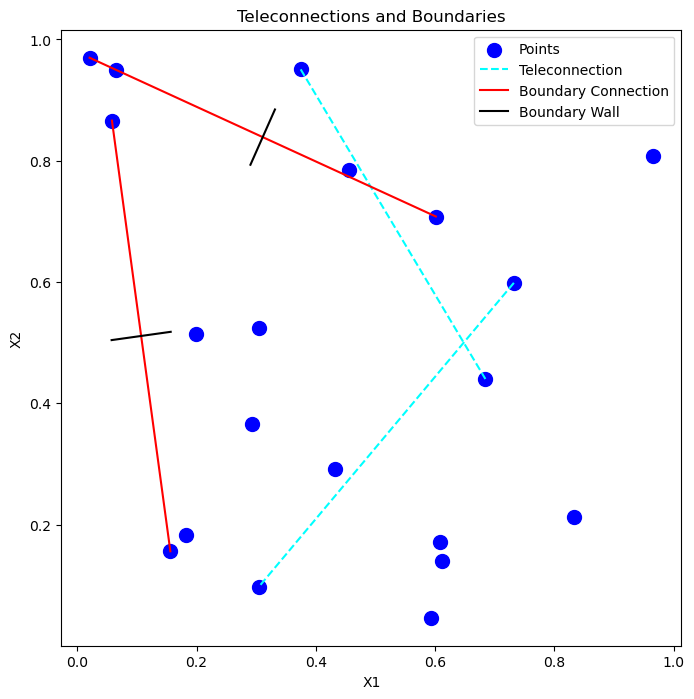

Initializing distances...


In [127]:
# Step 7: Generate synthetic data
print("Generating synthetic data...")
X, Y, planted_teleconnections, planted_boundaries = generate_synthetic_data(n_points=20, k_genes=3)
# Step 1: Initialize distance and variance matrices
print("Initializing distances...")
M_0, T = initialize_distances(X, Y)

Learning pseudo-distances...


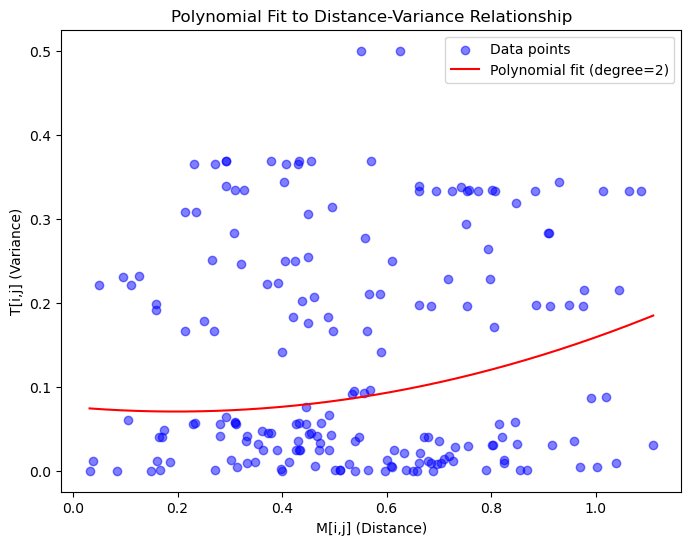

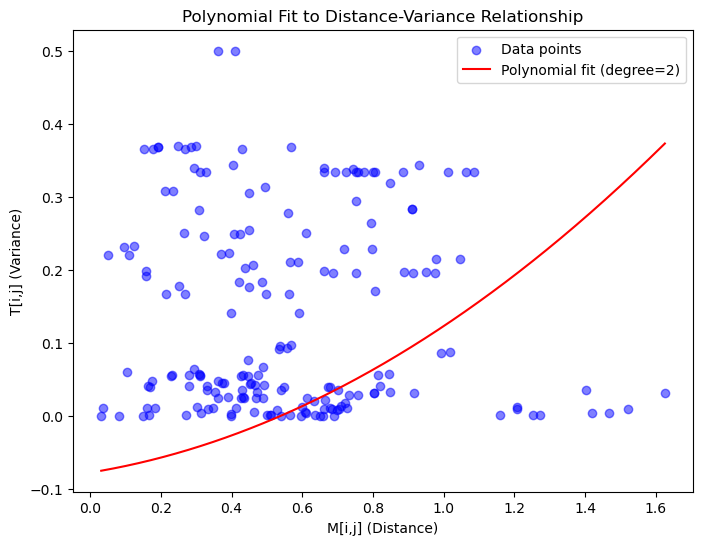

Identifying teleconnections and boundaries...
Visualizing results...


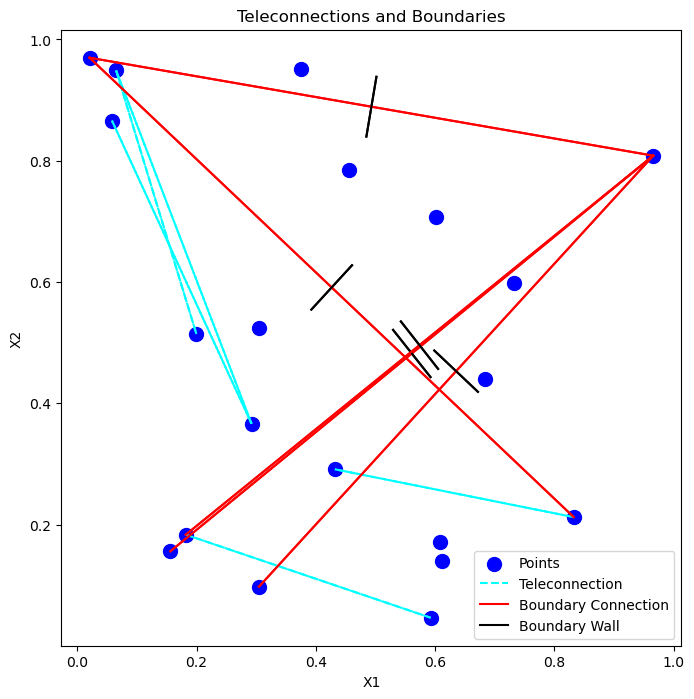


--- Planted vs Detected Relationships ---
Planted Teleconnections: [(0, 19), (1, 18)]
Detected Teleconnections: [(3, 11), (6, 9), (7, 14), (9, 6), (11, 3), (11, 16), (13, 16), (14, 7), (16, 11), (16, 13)]
Planted Boundaries: [(2, 3), (4, 5)]
Detected Boundaries: [(2, 17), (5, 6), (5, 17), (6, 5), (7, 17), (17, 2), (17, 5), (17, 7), (17, 18), (18, 17)]


In [128]:


# Step 4: Learn pseudo-distances iteratively
print("Learning pseudo-distances...")
M_inf, _ = learn_pseudo_distances(X, Y, num_iterations=5, degree=2, alpha=0.1)

# Step 5: Identify teleconnections and boundaries
print("Identifying teleconnections and boundaries...")
teleconnections, boundaries = identify_relationships(M_0, M_inf, quantile=0.025)

# Step 6: Visualize the results
print("Visualizing results...")
visualize_results(X, teleconnections, boundaries)

# Print planted vs detected relationships
print("\n--- Planted vs Detected Relationships ---")
print(f"Planted Teleconnections: {planted_teleconnections}")
print(f"Detected Teleconnections: {teleconnections}")
print(f"Planted Boundaries: {planted_boundaries}")
print(f"Detected Boundaries: {boundaries}")

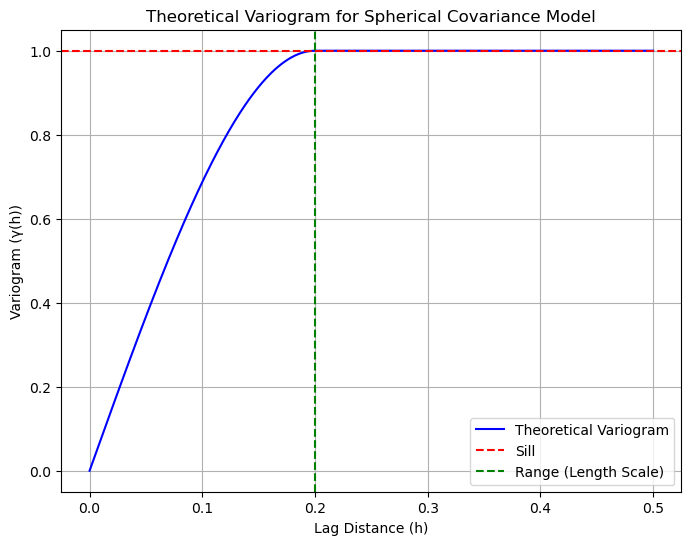

In [129]:
import numpy as np
import matplotlib.pyplot as plt

def plot_theoretical_variogram(length_scale=0.2, sill=1.0, max_distance=1.0, num_points=500):
    """
    Plot the theoretical variogram for the spherical covariance model.

    Args:
        length_scale (float): Range of the spherical model (radius of influence).
        sill (float): Sill value, the maximum variogram value.
        max_distance (float): Maximum distance to plot the variogram.
        num_points (int): Number of points to sample for the plot.
    """
    # Define the lag distances
    distances = np.linspace(0, max_distance, num_points)

    # Compute the variogram
    variogram = np.zeros_like(distances)
    for i, h in enumerate(distances):
        if h <= length_scale:
            variogram[i] = sill * (1.5 * (h / length_scale) - 0.5 * (h / length_scale) ** 3)
        else:
            variogram[i] = sill

    # Plot the variogram
    plt.figure(figsize=(8, 6))
    plt.plot(distances, variogram, label="Theoretical Variogram", color="blue")
    plt.axhline(sill, color="red", linestyle="--", label="Sill")
    plt.axvline(length_scale, color="green", linestyle="--", label="Range (Length Scale)")
    plt.xlabel("Lag Distance (h)")
    plt.ylabel("Variogram (γ(h))")
    plt.title("Theoretical Variogram for Spherical Covariance Model")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
plot_theoretical_variogram(length_scale=0.2, sill=1.0, max_distance=0.5)

In [130]:
X

array([[0.37454012, 0.95071431],
       [0.73199394, 0.59865848],
       [0.15601864, 0.15599452],
       [0.05808361, 0.86617615],
       [0.60111501, 0.70807258],
       [0.02058449, 0.96990985],
       [0.83244264, 0.21233911],
       [0.18182497, 0.18340451],
       [0.30424224, 0.52475643],
       [0.43194502, 0.29122914],
       [0.61185289, 0.13949386],
       [0.29214465, 0.36636184],
       [0.45606998, 0.78517596],
       [0.19967378, 0.51423444],
       [0.59241457, 0.04645041],
       [0.60754485, 0.17052412],
       [0.06505159, 0.94888554],
       [0.96563203, 0.80839735],
       [0.30461377, 0.09767211],
       [0.68423303, 0.44015249]])

In [131]:
Y

array([[0.        , 0.07980176, 0.        ],
       [0.        , 0.        , 0.        ],
       [0.23109016, 0.        , 0.11664804],
       [1.        , 0.        , 1.        ],
       [0.49005567, 0.        , 0.        ],
       [0.4311194 , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.32656086, 0.        , 0.19623458],
       [0.91967601, 1.        , 0.58666865],
       [0.        , 0.        , 0.58265255],
       [0.        , 1.        , 0.        ],
       [0.05198738, 0.        , 0.22809605],
       [0.        , 0.46380998, 0.        ],
       [0.46138951, 1.        , 1.        ],
       [0.        , 0.        , 0.57526526],
       [1.        , 0.        , 1.        ],
       [0.        , 0.        , 0.16424714],
       [0.        , 0.        , 0.        ],
       [0.        , 0.07980176, 0.        ]])